# Gibbs Sampler and EM for Mixture Models

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm

## Mixture Models

We observe data $y_1, \dots, y_n$. Consider the model: $y_i \overset{\text{i.i.d}}{\sim} p N(\mu_1, 1) + (1-p) N(\mu_2, 1)$. The unknown parameters are $\mu_1, \mu_2, p$. For simplicity, let us first assume that $p \in (0, 1)$ is also known so the unknowns are $\mu_1$ and $\mu_2$. The likelihood is given by: 
\begin{align*}
   \prod_{i=1}^n \left(p \phi(y_i - \mu_1) + (1-p) \phi(y_i - \mu_2) \right)
\end{align*}
where $\phi(\cdot)$ is the standard normal pdf. 

Consider the following simulated dataset from this model. This simulation example is from Chapter 6 of the book "Bayesian Essentials with R" by Marin and Robert. I recommend reading this book chapter for more details.  


In [ ]:
n = 500
q = 0.7
p = 1 - q
mu1_true = 2.5
mu2_true = 0.0

np.random.seed(0)
# latent component indicators
z = np.random.rand(n) < q

# generate data
y = np.where(z, np.random.normal(mu2_true, 1, n), np.random.normal(mu1_true, 1, n))

Below we plot the histogram for this dataset along with the true density. 

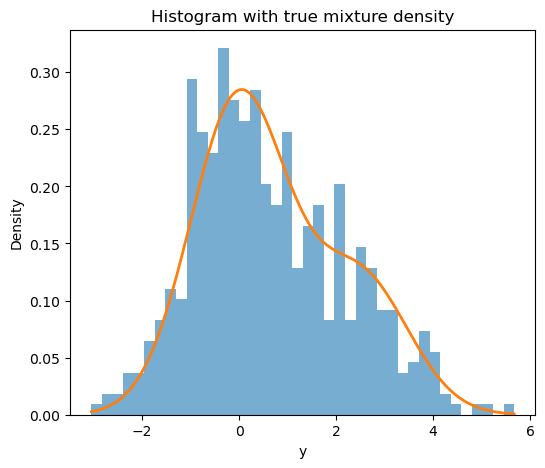

In [ ]:
x = np.linspace(y.min(), y.max(), 500)

true_density = (1 - q) * norm.pdf(x, mu1_true, 1) + q * norm.pdf(x, mu2_true, 1)

plt.figure(figsize=(6,5))
plt.hist(y, bins=40, density=True, alpha=0.6)
plt.plot(x, true_density, linewidth=2)

plt.xlabel("y")
plt.ylabel("Density")
plt.title("Histogram with true mixture density")

plt.show()

Bayesian methods (and also non-Bayesian methods such as the EM algorithm for computing the MLE) crucially rely on the likelihood (as well as the log-likelihood). Below we plot the log-likelihood as a function of $\mu_1$ and $\mu_2$. 

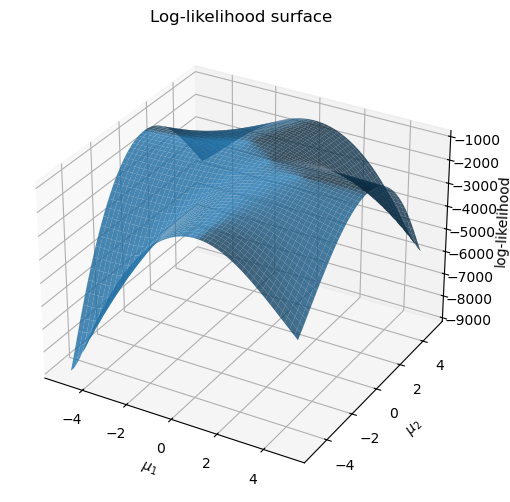

In [ ]:
def loglik(mu1, mu2, y, q):
    comp1 = (1 - q) * norm.pdf(y[:, None, None] - mu1)
    comp2 = q * norm.pdf(y[:, None, None] - mu2)
    return np.sum(np.log(comp1 + comp2), axis=0)

mu1_grid = np.linspace(-5, 5, 200)
mu2_grid = np.linspace(-5, 5, 200)

M1, M2 = np.meshgrid(mu1_grid, mu2_grid, indexing="xy")
LL = loglik(M1, M2, y, q)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(M1, M2, LL, alpha=0.8)

ax.set_xlabel(r'$\mu_1$')
ax.set_ylabel(r'$\mu_2$')
ax.set_zlabel('log-likelihood')

plt.title("Log-likelihood surface")
plt.show()

The log-likelihood does not seem like having a single mode; in fact, it has two modes as can be seen from the contour plot below. Notice however the scale of the z-axis in the log-likelihood plot. 

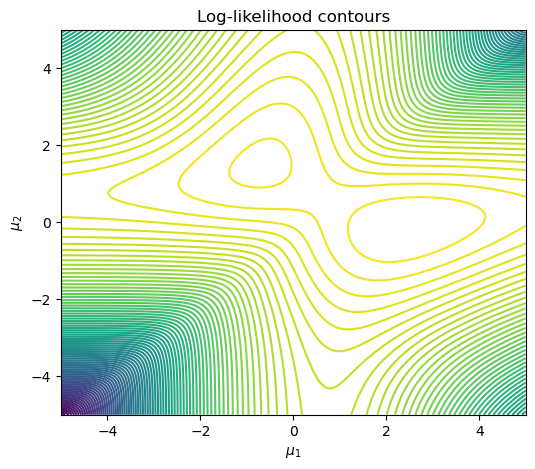

In [ ]:
plt.figure(figsize=(6,5))
plt.contour(M1, M2, LL, levels=100)
plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours")
plt.show()

Of these two modes, one of them is quite close to the true values of $\mu_1$ and $\mu_2$ (which are $2.5$ and 0 respectively). The other one is a spurious mode. We should careful with any algorithm that tries to optimize (or sample from the posterior) based on the log-likelihood because it might be attracted by the spurious mode. 

If we look at the likelihood function (instead of the log-likelihood), it turns out it is extremely peaked with only one visible mode (which is close to the true values of $\mu_1$ and $\mu_2$). This is shown below. 

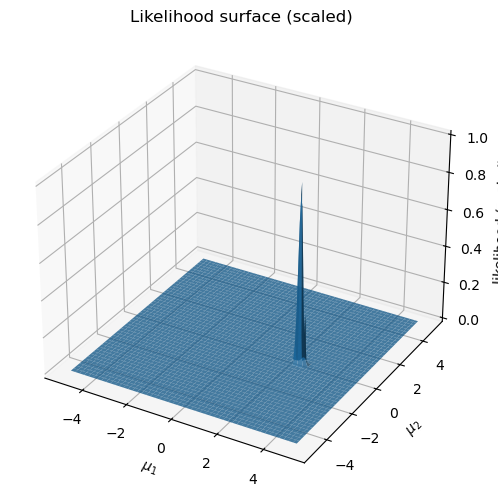

In [ ]:
# stabilize before exponentiating
LL_shifted = LL - np.max(LL)
L = np.exp(LL_shifted)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(M1, M2, L, alpha=0.8)

ax.set_xlabel(r'$\mu_1$')
ax.set_ylabel(r'$\mu_2$')
ax.set_zlabel('likelihood (scaled)')

plt.title("Likelihood surface (scaled)")
plt.show()

It is remarkable that the bimodal structure in the log-likelihood seemingly disappears when we look at the likelihood which has a very clear and sharp peak. However, algorithms cannot directly run on the likelihood because it is mostly zero except for a very tiny region around the MLE. Note also that we have normalized the likelihood here so that the maximum is equal to 1. 

### The EM Algorithm

Before discussing the Gibbs sampler, let us first see how the EM algorithm works. The EM algorithm is an iterative algorithm applied to the log-likelihood for computing the MLE. It is very similar in spirit to the Gibbs sampler. The EM algorithm is coded below, we shall look at the algorithm in the next lecture. 

In [ ]:
def em_gaussian_mixture(y, mu1_init, mu2_init, q=0.7,
                        max_iter=200, tol=1e-6):
    
    mu1 = mu1_init
    mu2 = mu2_init
    
    loglik_trace = []
    mu1_trace = [mu1]
    mu2_trace = [mu2]
    
    for t in range(max_iter):
        
        # ----- E-step -----
        f1 = (1 - q) * norm.pdf(y, loc=mu1, scale=1)
        f2 = q * norm.pdf(y, loc=mu2, scale=1)
        
        gamma = f2 / (f1 + f2)
        
        # ----- M-step -----
        mu1_new = np.sum((1 - gamma) * y) / np.sum(1 - gamma)
        mu2_new = np.sum(gamma * y) / np.sum(gamma)
        
        # ----- log-likelihood -----
        ll = np.sum(np.log(f1 + f2))
        loglik_trace.append(ll)
        
        mu1_trace.append(mu1_new)
        mu2_trace.append(mu2_new)
        
        # convergence
        if np.abs(mu1_new - mu1) < tol and np.abs(mu2_new - mu2) < tol:
            break
        
        mu1, mu2 = mu1_new, mu2_new
    
    return {
        "mu1": mu1,
        "mu2": mu2,
        "loglik": loglik_trace,
        "mu1_path": mu1_trace,
        "mu2_path": mu2_trace
    }

The EM algorithm needs an initial value for the parameters. Its behaviour could be different for different starting values as shown below. 

In [ ]:
#consider the following initial values for the EM. 
#these values are chosen to be far from the true values (mu1_true = 2.5, mu2_true = 0.0)
mu1_init = 0.0
mu2_init = 3.0 
res = em_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7)
print(res["mu1"], res["mu2"])

-0.6608832392943691 1.481701314811594


Here the EM algorithm converged to two values which are far from the true values. We can plot the EM iterates on the contour plot of the log-likelihood as shown below. 

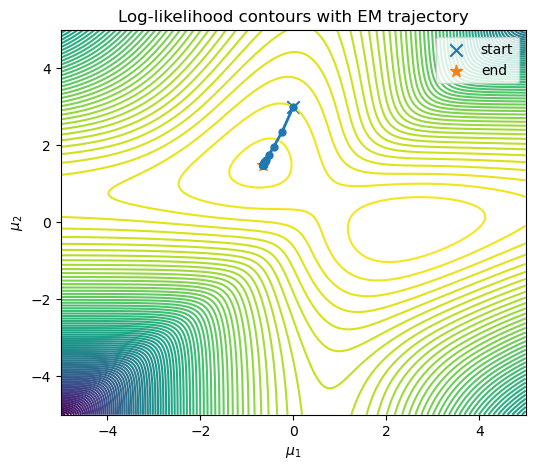

In [ ]:
plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# EM path
mu1_path = np.array(res["mu1_path"])
mu2_path = np.array(res["mu2_path"])

plt.plot(mu1_path, mu2_path, marker='o', markersize = 5, linewidth=2)

# highlight start and end
plt.scatter(mu1_path[0], mu2_path[0], s=80, marker='x', label='start')
plt.scatter(mu1_path[-1], mu2_path[-1], s=80, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with EM trajectory")

plt.legend()
plt.show()

It is clear from the above plot that the EM algorithm is converging to the spurious mode (as opposed to the correct mode). This solution does not explain the data well as is clear from the histogram of the data superimposed on the fitted density. 

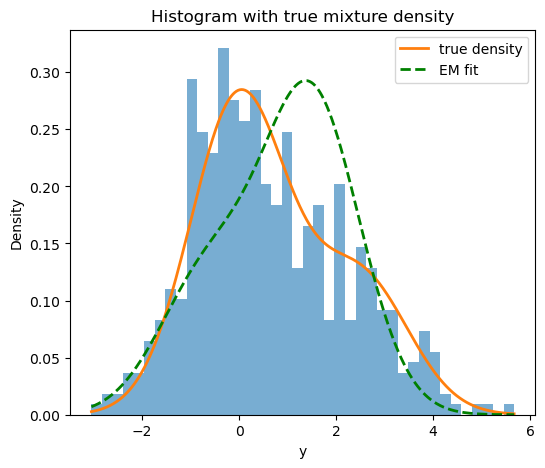

In [ ]:
x = np.linspace(y.min(), y.max(), 500)
true_density = (1 - q) * norm.pdf(x, mu1_true, 1) + q * norm.pdf(x, mu2_true, 1)

mu1_alt = res["mu1"]
mu2_alt = res["mu2"]
alt_density = (1 - q) * norm.pdf(x, mu1_alt, 1) + q * norm.pdf(x, mu2_alt, 1)

plt.figure(figsize=(6,5))
plt.hist(y, bins=40, density=True, alpha=0.6)
plt.plot(x, true_density, linewidth=2, label = 'true density')
plt.plot(x, alt_density, linewidth=2, color='green', linestyle='--', label='EM fit')

plt.xlabel("y")
plt.ylabel("Density")
plt.title("Histogram with true mixture density")
plt.legend()

plt.show()

Below we take a different initialization for which the EM algorithm converges to the actual MLE. 

2.4614802836432386 -0.14232302968100255


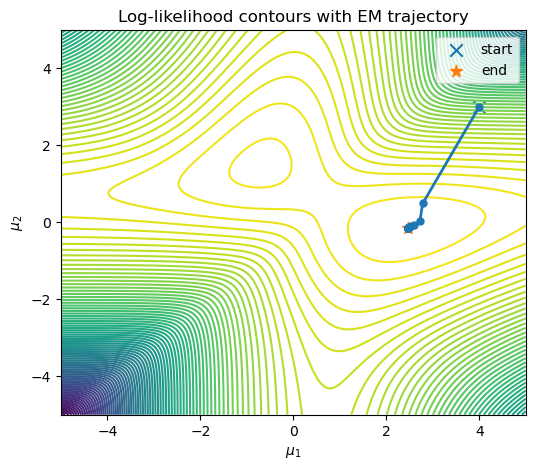

In [ ]:
mu1_init = 4.0
mu2_init = 3.0 
res = em_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7)
print(res["mu1"], res["mu2"])

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# EM path
mu1_path = np.array(res["mu1_path"])
mu2_path = np.array(res["mu2_path"])

plt.plot(mu1_path, mu2_path, marker='o', markersize = 5, linewidth=2)

# highlight start and end
plt.scatter(mu1_path[0], mu2_path[0], s=80, marker='x', label='start')
plt.scatter(mu1_path[-1], mu2_path[-1], s=80, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with EM trajectory")

plt.legend()
plt.show()

If we initialize the EM algorithm randomly, one can still end up at the spurious mode. To see this, run the following a few times. 

-0.6608830263873635 1.481701707295715


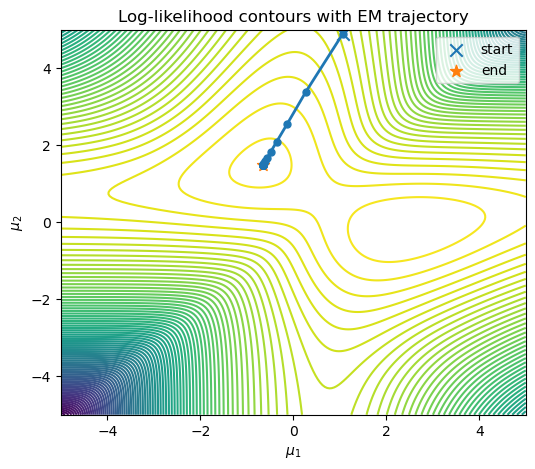

In [ ]:
mu1_init = np.random.uniform(-5, 5)
mu2_init = np.random.uniform(-5, 5)
res = em_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7)
print(res["mu1"], res["mu2"])

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# EM path
mu1_path = np.array(res["mu1_path"])
mu2_path = np.array(res["mu2_path"])

plt.plot(mu1_path, mu2_path, marker='o', markersize = 5, linewidth=2)

# highlight start and end
plt.scatter(mu1_path[0], mu2_path[0], s=80, marker='x', label='start')
plt.scatter(mu1_path[-1], mu2_path[-1], s=80, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with EM trajectory")

plt.legend()
plt.show()

Another interesting initialization for the EM algorithm is when $\mu_1 = \mu_2$. In this case, it turns out that the EM algorithm converges (in one step!) to $(\bar{y}, \bar{y})$. So in this case, the algorithm does not even converge to one of the two modes. Instead it converges to the MLE in the single Gaussian model $N(\mu, 1)$. This can be verified below. 

0.6318113722352241 0.631811372235224


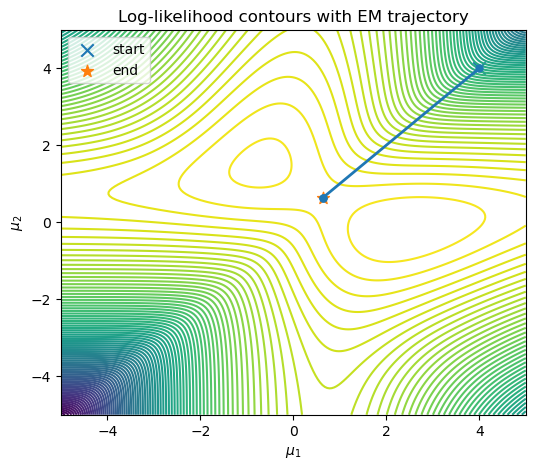

In [ ]:
mu1_init = 4.0
mu2_init = 4.0
res = em_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7)
print(res["mu1"], res["mu2"])

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# EM path
mu1_path = np.array(res["mu1_path"])
mu2_path = np.array(res["mu2_path"])

plt.plot(mu1_path, mu2_path, marker='o', markersize = 5, linewidth=2)

# highlight start and end
plt.scatter(mu1_path[0], mu2_path[0], s=80, marker='x', label='start')
plt.scatter(mu1_path[-1], mu2_path[-1], s=80, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with EM trajectory")

plt.legend()
plt.show()

### The Gibbs Sampler

Next let us look at the Gibbs sampler. Gibbs sampler works by augmentation (similar to the probit regression example) and we shall look at the formulae in the next lecture. The code for the Gibbs sampler is given below. 

In [ ]:
def gibbs_gaussian_mixture(y, mu1_init, mu2_init, q=0.7,
                          tau2=1000, n_iter=5000):
    
    n = len(y)
    
    mu1 = mu1_init
    mu2 = mu2_init
    
    mu1_trace = []
    mu2_trace = []
    
    # initialize Z randomly
    z = np.random.rand(n) < q
    
    for t in range(n_iter):
        
        # ----- Sample Z -----
        f1 = (1 - q) * norm.pdf(y, loc=mu1)
        f2 = q * norm.pdf(y, loc=mu2)
        
        prob = f2 / (f1 + f2)
        z = np.random.rand(n) < prob
        
        # ----- Sample mu1 -----
        y1 = y[~z]
        n1 = len(y1)
        
        var1 = 1 / (n1 + 1/tau2)
        mean1 = var1 * np.sum(y1)
        
        mu1 = np.random.normal(mean1, np.sqrt(var1))
        
        # ----- Sample mu2 -----
        y2 = y[z]
        n2 = len(y2)
        
        var2 = 1 / (n2 + 1/tau2)
        mean2 = var2 * np.sum(y2)
        
        mu2 = np.random.normal(mean2, np.sqrt(var2))
        
        mu1_trace.append(mu1)
        mu2_trace.append(mu2)
    
    return {
        "mu1": np.array(mu1_trace),
        "mu2": np.array(mu2_trace)
    }

Similar to the EM algorithm, the Gibbs sampler also needs an initialization. We can run the Gibbs sampler with the same initial values that we used previously for the EM. Let us start with the first set of initial values. 

In [ ]:
mu1_init = 0.0
mu2_init = 3.0 

res_gibbs = gibbs_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7)

mu1_samples = res_gibbs["mu1"]
mu2_samples = res_gibbs["mu2"]

Let us plot the Gibbs iterates below on contours. 

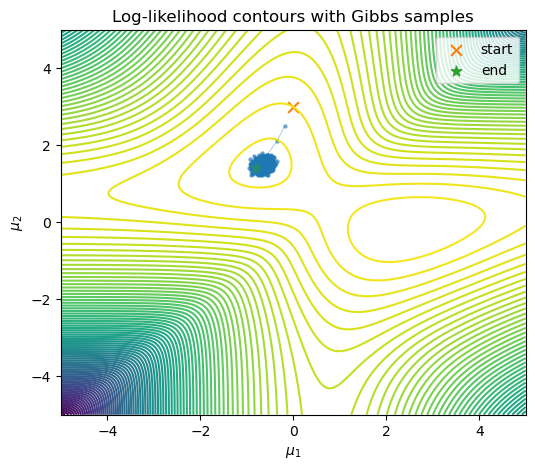

In [ ]:
plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# Gibbs samples
mu1_samp = res_gibbs["mu1"]
mu2_samp = res_gibbs["mu2"]

mu1_post = mu1_samp
mu2_post = mu2_samp

# plot full path (light line)
plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)

# scatter samples (posterior cloud)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

# highlight start and end
plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(mu1_samp[-1], mu2_samp[-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with Gibbs samples")

plt.legend()
plt.show()

Similar to the EM algorithm, the Gibbs sampler is only exploring the first peak of the posterior (note that this peak corresponds to the spurious mode). Let us now look at the second set of initial values. 

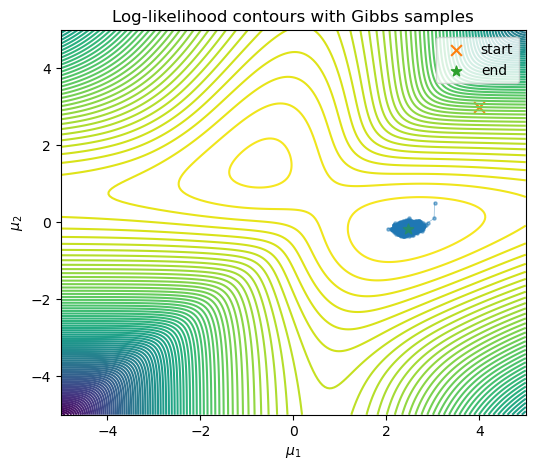

In [ ]:
mu1_init = 4.0
mu2_init = 3.0 

res_gibbs = gibbs_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7)

mu1_samples = res_gibbs["mu1"]
mu2_samples = res_gibbs["mu2"]

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# Gibbs samples
mu1_samp = res_gibbs["mu1"]
mu2_samp = res_gibbs["mu2"]

mu1_post = mu1_samp
mu2_post = mu2_samp

# plot full path (light line)
plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)

# scatter samples (posterior cloud)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

# highlight start and end
plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(mu1_samp[-1], mu2_samp[-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with Gibbs samples")

plt.legend()
plt.show()

In this case, the Gibbs samples are concentrated at the correct mode. Next let us look at random initializations. Repeat the following multiple times. There will be a few times the Gibbs samples focus on the spurious peak. 

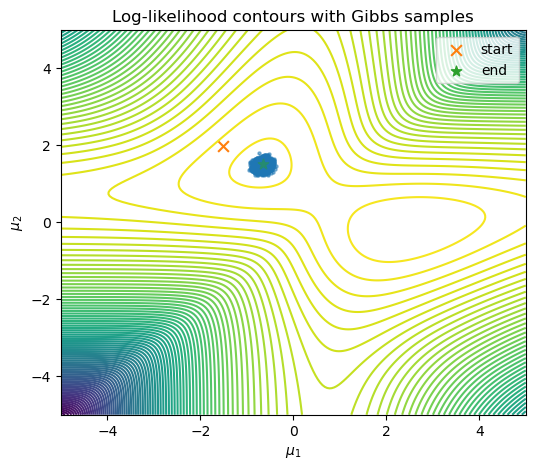

In [ ]:
mu1_init = np.random.uniform(-5, 5)
mu2_init = np.random.uniform(-5, 5)
res_gibbs = gibbs_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7)

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# Gibbs samples
mu1_samp = res_gibbs["mu1"]
mu2_samp = res_gibbs["mu2"]

mu1_post = mu1_samp
mu2_post = mu2_samp

# plot full path (light line)
plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)

# scatter samples (posterior cloud)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

# highlight start and end
plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(mu1_samp[-1], mu2_samp[-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with Gibbs samples")

plt.legend()
plt.show()

Next look at the case of the initialization $\mu_1 = \mu_2$. In this case, the EM algorithm converges in one step to $(\bar{y}, \bar{y})$. Let us see how the Gibbs sampler performs. In this case (as can be seen from the code below), some times, the Gibbs sampler goes to the correct mode, but some other times, it will go to the spurious mode. This is an unstable initialization. 

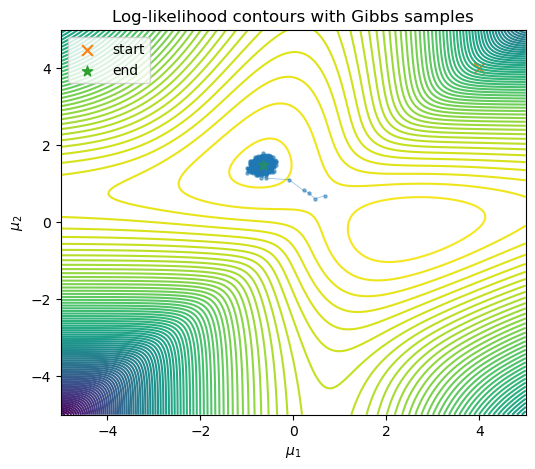

In [ ]:
mu1_init = 4.0
mu2_init = 4.0
res_gibbs = gibbs_gaussian_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7)

plt.figure(figsize=(6,5))

# contour
plt.contour(M1, M2, LL, levels=100)

# Gibbs samples
mu1_samp = res_gibbs["mu1"]
mu2_samp = res_gibbs["mu2"]

mu1_post = mu1_samp
mu2_post = mu2_samp

# plot full path (light line)
plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)

# scatter samples (posterior cloud)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

# highlight start and end
plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(mu1_samp[-1], mu2_samp[-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with Gibbs samples")

plt.legend()
plt.show()

Overall, the Gibbs sampler has very similar problems to the EM in this example.  Initialization is important and it is quite possible that the Gibbs samples are exploring the wrong peak of the log-posterior. 

### Metropolis Algorithm

Next let us look at the performance of the Random-Walk Metropolis Algorithm. The code is given below. We are generating proposals by $y = x + z$ where $z \sim N(0, s^2 I_2)$ for a step size $s$. 

In [ ]:
def loglik(mu1, mu2, y, q):
    return np.sum(np.log((1 - q) * norm.pdf(y, mu1, 1) +
                         q * norm.pdf(y, mu2, 1)))

def rwm_mixture(y, mu1_init, mu2_init, q=0.7,
                n_iter=5000, step_size=1.0):
    
    mu1 = mu1_init
    mu2 = mu2_init
    
    mu1_trace = []
    mu2_trace = []
    
    accept = 0
    
    current_ll = loglik(mu1, mu2, y, q)
    
    for t in range(n_iter):
        
        # ----- proposal -----
        proposal = np.random.normal(0, step_size, size=2)
        mu1_prop = mu1 + proposal[0]
        mu2_prop = mu2 + proposal[1]
        
        # ----- compute log-likelihood -----
        prop_ll = loglik(mu1_prop, mu2_prop, y, q)
        
        # ----- accept/reject -----
        log_alpha = prop_ll - current_ll
        
        if np.log(np.random.rand()) < log_alpha:
            mu1, mu2 = mu1_prop, mu2_prop
            current_ll = prop_ll
            accept += 1
        
        mu1_trace.append(mu1)
        mu2_trace.append(mu2)
    
    return {
        "mu1": np.array(mu1_trace),
        "mu2": np.array(mu2_trace),
        "accept_rate": accept / n_iter
    }

The step size is crucial for the algorithm. When the step size equals 1, the Metropolis algorithm works correctly (i.e., has samples concentrated at the correct log-posterior mode) for all the initializations that we looked at previously. However the acceptance rate of the chain will be small. 

Acceptance rate: 0.01306


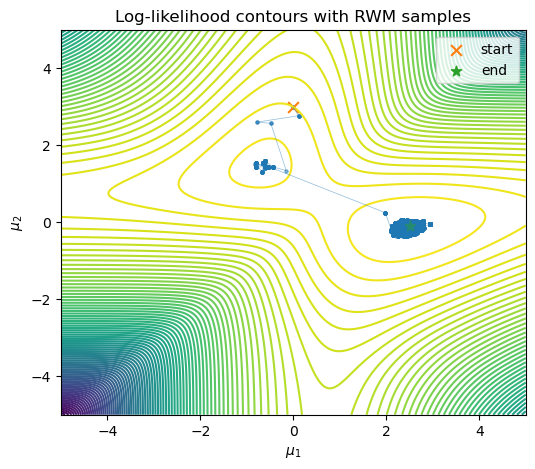

In [ ]:
#First initialization
mu1_init = 0.0
mu2_init = 3.0

#Second initialization
#mu1_init = 4.0
#mu2_init = 3.0

#Random Initialization
#mu1_init = np.random.uniform(-5, 5)
#mu2_init = np.random.uniform(-5, 5)

#Fourth Initialization
#mu1_init = 4.0
#mu2_init = 4.0

res_rwm = rwm_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7, n_iter=100000, step_size = 1.0)

print("Acceptance rate:", res_rwm["accept_rate"])

plt.figure(figsize=(6,5))
plt.contour(M1, M2, LL, levels=100)

burn = 0
mu1_post = res_rwm["mu1"][burn:]
mu2_post = res_rwm["mu2"][burn:]

plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(res_rwm["mu1"][-1], res_rwm["mu2"][-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with RWM samples")

plt.legend()
plt.show()

On the other hand, when the step size is smaller (in this example, 0.5 or smaller), then the Metropolis algorithm behaves similarly to the Gibbs sampler case (with the possibility of exploring the spurious mode for certain initializations). 

Acceptance rate: 0.04914


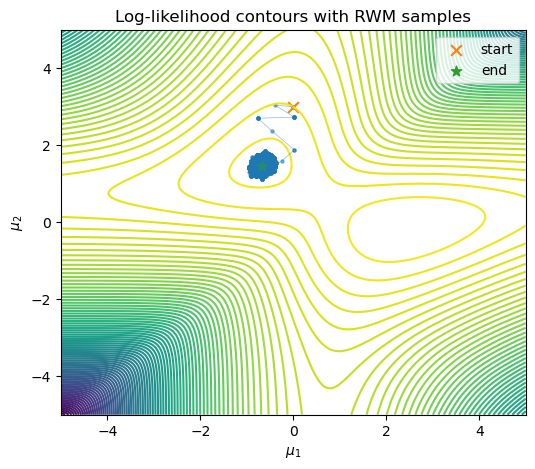

In [ ]:
#First initialization
mu1_init = 0.0
mu2_init = 3.0

#Second initialization
#mu1_init = 4.0
#mu2_init = 3.0

#Random Initialization
#mu1_init = np.random.uniform(-5, 5)
#mu2_init = np.random.uniform(-5, 5)

#Fourth Initialization
#mu1_init = 4.0
#mu2_init = 4.0

res_rwm = rwm_mixture(y, mu1_init=mu1_init, mu2_init=mu2_init, q=0.7, n_iter=100000, step_size = 0.5)

print("Acceptance rate:", res_rwm["accept_rate"])

plt.figure(figsize=(6,5))
plt.contour(M1, M2, LL, levels=100)

burn = 0
mu1_post = res_rwm["mu1"][burn:]
mu2_post = res_rwm["mu2"][burn:]

plt.plot(mu1_post, mu2_post, linewidth=0.5, alpha=0.5)
plt.scatter(mu1_post, mu2_post, s=5, alpha=0.5)

plt.scatter(mu1_init, mu2_init, s=60, marker='x', label='start')
plt.scatter(res_rwm["mu1"][-1], res_rwm["mu2"][-1], s=60, marker='*', label='end')

plt.xlabel(r'$\mu_1$')
plt.ylabel(r'$\mu_2$')
plt.title("Log-likelihood contours with RWM samples")

plt.legend()
plt.show()

Overall, the summary from this simple simulation exercise is that the Gibbs sampler is sensitive to initialization in this simple mixture model. The Random-Walk Metropolis algorithm works with a large enough scale for the proposal chain. 